# FITTING T1 & T2 COHERENT DECAY 

### 1. LOAD DATA

In [2]:
import glob
import os
from datetime import datetime
import numpy as np

# ==========================================================
# Search configuration
# Each block corresponds to one measurement batch
# =================================================
beta_scale = 1.6468200333233496
search_configs = [
    {
        "data_dir": r"E:\CQT\Fast Flux\fitting_coherent_decay\data_coherent",
        "start": "00-08-07",
        "stop":  "22-46-27",
        "decays": np.array([4_000, 7_000, 11_000, 15_000, 20_000, 35_000, 50_000, 100_000, 4, 25_000, 1_000, 2_000])*4 # In ns (remove 4 for clock cycles)
    },
#     
]

# ==========================================================
# Collect files and assign decay values
# ==========================================================
paired_data = []

for cfg in search_configs:

    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):

        filename = os.path.basename(file_path)

        if "Char_Func_2D_decay_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0],
                "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["decays"]):
        raise ValueError(
            f"Expected {len(cfg['decays'])} files, "
            f"but found {len(files)}."
        )

    for decay, file in zip(cfg["decays"], files):
        paired_data.append((decay, file))

# ==========================================================
# Sort by decay time for plotting
# ==========================================================
paired_data.sort(key=lambda x: x[0])

decay_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

# ==========================================================
# Print result
# ==========================================================
print("\nFiles in decay order:\n")

for decay, file in zip(decay_sweep_sorted, collected_files_sorted):

    if decay >= 1000:
        label = f"{decay/1000:g} us"
    else:
        label = f"{decay:g} ns"

    print(f"{label:>8}  -->  {os.path.basename(file)}")


Batch: E:\CQT\Fast Flux\fitting_coherent_decay\data_coherent
Found 12 files

Files in decay order:

   16 ns  -->  18-55-28_Char_Func_2D_decay_sweep.hdf5
    4 us  -->  21-48-12_Char_Func_2D_decay_sweep.hdf5
    8 us  -->  22-46-27_Char_Func_2D_decay_sweep.hdf5
   16 us  -->  00-08-07_Char_Func_2D_decay_sweep.hdf5
   28 us  -->  01-47-27_Char_Func_2D_decay_sweep.hdf5
   44 us  -->  03-27-08_Char_Func_2D_decay_sweep.hdf5
   60 us  -->  05-07-20_Char_Func_2D_decay_sweep.hdf5
   80 us  -->  06-48-01_Char_Func_2D_decay_sweep.hdf5
  100 us  -->  19-53-37_Char_Func_2D_decay_sweep.hdf5
  140 us  -->  08-29-19_Char_Func_2D_decay_sweep.hdf5
  200 us  -->  10-12-28_Char_Func_2D_decay_sweep.hdf5
  400 us  -->  13-34-43_Char_Func_2D_decay_sweep.hdf5


### 2. PLOT DATA

Loaded 12 characteristic functions.
State array shape: (12, 33, 33)


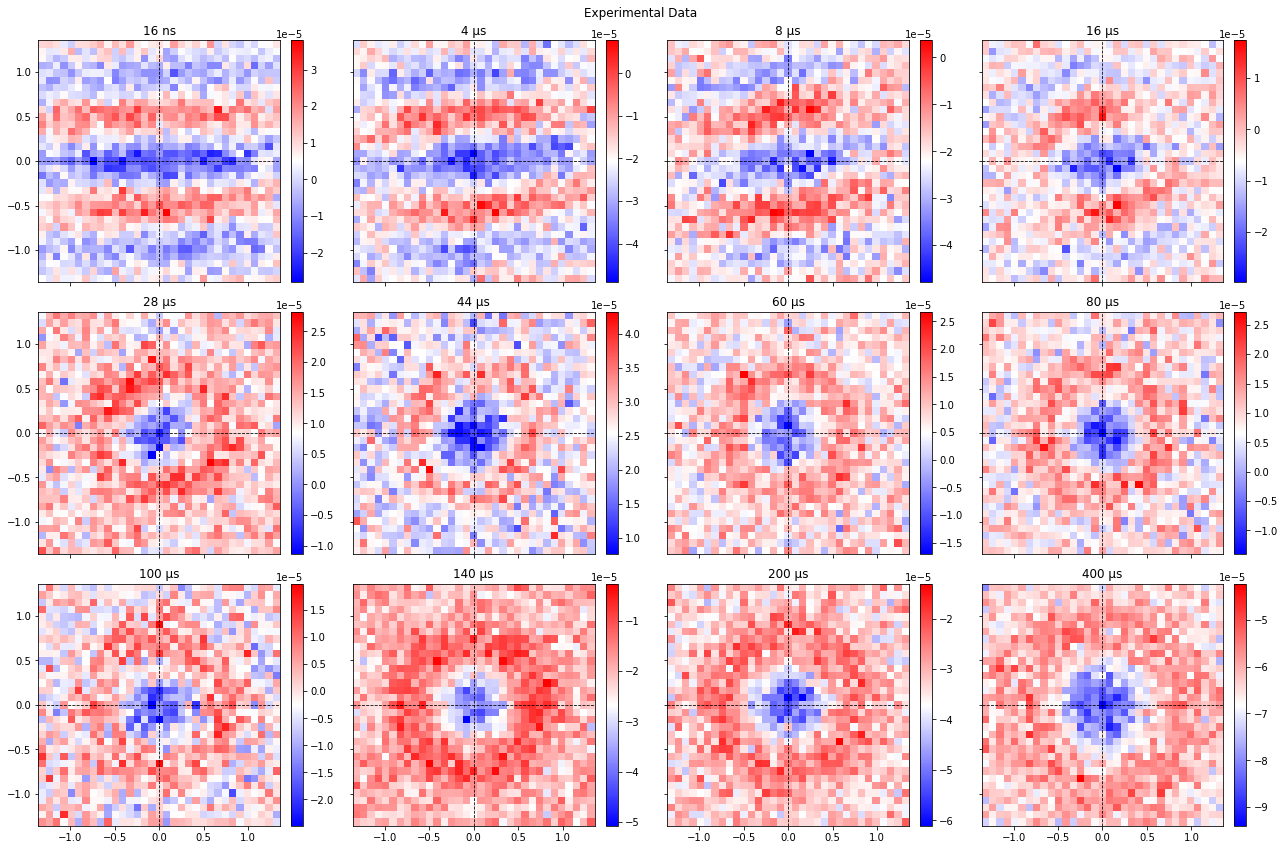

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# Load experimental data
# ==========================================================

state_list = []
x_list = []
y_list = []

for decay, file_path in zip(decay_sweep_sorted, collected_files_sorted):

    with h5py.File(file_path, "r") as data:

        state = np.mean(np.array(data["I"]), axis=0)

        x = beta_scale * np.array(data["x_displace"])
        y = beta_scale * np.array(data["y_displace"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)

state_list = np.asarray(state_list)
x_list = np.asarray(x_list)
y_list = np.asarray(y_list)

print(f"Loaded {len(state_list)} characteristic functions.")
print("State array shape:", state_list.shape)

# ==========================================================
# Plot function
# ==========================================================

def plot_characteristic_functions(
    charfuncs,
    x_list,
    y_list,
    decay_times,
    title="Characteristic Functions",
):

    n = len(charfuncs)

    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18,12),
        sharex=True,
        sharey=True,
    )

    axes = np.ravel(axes)

    for i in range(n):

        ax = axes[i]

        im = ax.pcolormesh(
            x_list[i],
            y_list[i],
            charfuncs[i],
            shading="auto",
            cmap="bwr",
        )

        ax.axvline(0, color="k", ls="--", lw=0.8)
        ax.axhline(0, color="k", ls="--", lw=0.8)

        ax.set_aspect("equal")

        decay = decay_times[i]

        if decay >= 1000:
            label = f"{decay/1000:g} μs"
        else:
            label = f"{decay:g} ns"

        ax.set_title(label)

        plt.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ==========================================================
# Plot experiment
# ==========================================================

plot_characteristic_functions(
    state_list,
    x_list,
    y_list,
    decay_sweep_sorted,
    title="Experimental Data",
)

### 3. GENERATE SIMULATION FUNCTIONS

In [4]:
import numpy as np
import qutip as qt
from scipy.ndimage import rotate

# ==========================================================
# Select component
# ==========================================================

# Set Imag_part = True if fitting imaginary component
Imag_part = False


# ==========================================================
# Hilbert space
# ==========================================================

N_c = 30 # 

a = qt.destroy(N_c)

# ==========================================================
# Experimental beta grid
# ==========================================================

x = x_list[0]
y = y_list[0]

Nx = len(x)
Ny = len(y)

# ==========================================================
# Precompute displacement operators
# ==========================================================

print("Precomputing displacement operators...")

D_ops = [
    qt.displace(N_c, xr + 1j*yi)
    for yi in y
    for xr in x
]

print("Done.")

# ==========================================================
# Simulation
# ==========================================================

def simulate_characteristic_functions(
    T1,
    T2,
    detuning_MHz=0.0,
    angle_offset=0.0,
    alpha=3.0,
    dt=100,
):
    """
    Parameters
    ----------
    T1,T2 : ns

    detuning_MHz :
        Cavity detuning in MHz.

    angle_offset :
        Constant rotation applied AFTER simulation.

    alpha :
        Initial coherent amplitude.
    """

    rho0 = qt.coherent_dm(N_c, alpha)

    gamma1 = 1 / T1

    gamma_phi = max(
        0,
        1 / T2 - 1 / (2 * T1),
    )

    c_ops = [
        np.sqrt(gamma1) * a
    ]

    if gamma_phi > 0:

        c_ops.append(
            np.sqrt(2 * gamma_phi) * a.dag() * a
        )

    # ------------------------------------------------------
    # Hamiltonian
    # ------------------------------------------------------

    omega = 2 * np.pi * detuning_MHz / 1000.0

    H = omega * a.dag() * a

    exp_times = np.asarray(decay_sweep_sorted)

    t_dense = np.arange(
        0,
        exp_times.max() + dt,
        dt,
    )

    result = qt.mesolve(
        H,
        rho0,
        t_dense,
        c_ops=c_ops,
        options={
            "nsteps": 50000,
        },
    )

    states = []

    for t in exp_times:

        idx = np.argmin(
            np.abs(
                t_dense - t
            )
        )

        states.append(
            result.states[idx]
        )

    charfunc = []

    for rho in states:

        vals = qt.expect(
            D_ops,
            rho,
        ).reshape(
            Ny,
            Nx,
        )

        # ---------------------------------------------
        # Choose Real or Imaginary globally
        # ---------------------------------------------

        if Imag_part:

            img = np.imag(vals)

        else:

            img = -np.real(vals)

        # ---------------------------------------------
        # Constant offset only
        # ---------------------------------------------

        if abs(angle_offset) > 1e-9:

            img = rotate(
                img,
                angle_offset,
                reshape=False,
                order=1,
                mode="nearest",
            )

        charfunc.append(img)

    return np.asarray(charfunc)

print("Simulation function ready.")

print()

if Imag_part:
    print(">>> Using Imaginary part")
else:
    print(">>> Using Real part")

Precomputing displacement operators...
Done.
Simulation function ready.

>>> Using Real part


### 4. SIMULATE FOR GIVEN CAVITY T1 & T2


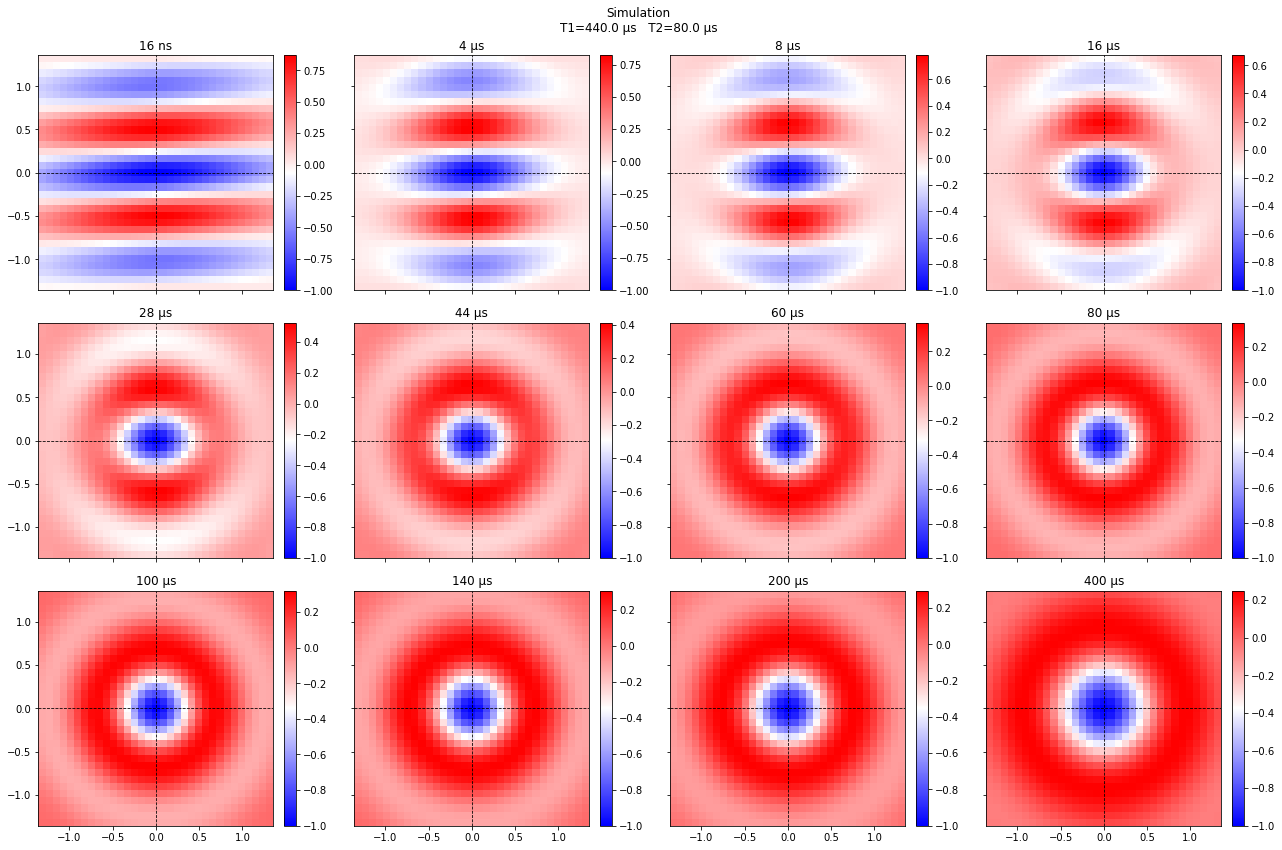

In [5]:
T1 = 110_000.0*4 #in ns
T2 = 20_000.0*4 #in ns

charfunc_sim = simulate_characteristic_functions(
    T1=T1,
    T2=T2,
    detuning_MHz=0.0,
    angle_offset=-2.0,
    alpha=3.0,
    
)

plot_characteristic_functions(
    charfunc_sim,
    x_list,
    y_list,
    decay_sweep_sorted,
    title=f"Simulation\nT1={T1/1000:.1f} μs   T2={T2/1000:.1f} μs",
)

### 5. DEFINE METRIC FOR COMPARISON AND FITTING ANGLES

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# ==========================================================
# Comparison settings
# ==========================================================

comparison_radius = 1.5

rotation_angles = np.linspace(
    -90,
    0,
    181,
)

X, Y = np.meshgrid(
    x_list[0],
    y_list[0],
)

mask = (
    X**2 + Y**2
) <= comparison_radius**2





# ==========================================================
# Correlation
# ==========================================================

def correlation(
    exp_img,
    sim_img,
):

    exp = exp_img[mask].copy()
    sim = sim_img[mask].copy()

    exp -= exp.mean()
    sim -= sim.mean()

    exp /= np.linalg.norm(exp)
    sim /= np.linalg.norm(sim)

    return np.sum(exp*sim)


# ==========================================================
# Search optimal angle
# ==========================================================

def best_rotated_simulation(
    exp_img,
    sim_img,
):

    best_overlap = -np.inf

    best_angle = 0

    best_sim = None

    for angle in rotation_angles:

        sim_rot = rotate(
            sim_img,
            angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        sim_fit, _, _ = affine_fit(
            exp_img,
            sim_rot,
        )

        overlap = correlation(
            exp_img,
            sim_fit,
        )

        if overlap > best_overlap:

            best_overlap = overlap
            best_angle = angle
            best_sim = sim_fit

    return (
        best_sim,
        best_overlap,
        best_angle,
    )


# ==========================================================
# Cost function
# ==========================================================

def residue(
    exp_data,
    sim_data,
):

    costs = []

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        sim_fit, overlap, angle = best_rotated_simulation(
            exp,
            sim,
        )

        diff = (
            exp[mask]
            -
            sim_fit[mask]
        )

        rms = np.sqrt(
            np.mean(
                diff**2
            )
        )

        rms /= np.std(
            exp[mask]
        )

        # Hybrid metric
        cost = (
            0.4*rms
            +
            0.6*(1-overlap)
        )

        costs.append(cost)

    return np.mean(costs)

# ==========================================================
# Cost function WITHOUT image rotation
#
# Used during the final optimization.
#
# The Hamiltonian is responsible for the rotation.
# ==========================================================

def residue_no_rotation(
    exp_data,
    sim_data,
):

    costs = []

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        sim_fit, _, _ = affine_fit(
            exp,
            sim,
        )

        overlap = correlation(
            exp,
            sim_fit,
        )

        diff = (
            exp[mask]
            -
            sim_fit[mask]
        )

        rms = np.sqrt(
            np.mean(
                diff**2
            )
        )

        rms /= np.std(
            exp[mask]
        )

        cost = (
            0.4*rms
            +
            0.6*(1-overlap)
        )

        costs.append(cost)

    return np.mean(costs)
# ==========================================================
# Obtain all optimal angles
# ==========================================================

def extract_rotation_angles(
    exp_data,
    sim_data,
):

    angles = []
    overlaps = []

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        _, overlap, angle = best_rotated_simulation(
            exp,
            sim,
        )

        angles.append(angle)
        overlaps.append(overlap)

    return (
        np.asarray(angles),
        np.asarray(overlaps),
    )


# ==========================================================
# Comparison figure
# ==========================================================

def compare_experiment_simulation(
    exp_data,
    sim_data,
    rotate_images=True,
):

    if rotate_images:

        angles, overlaps = extract_rotation_angles(
            exp_data,
            sim_data,
        )

    else:

        overlaps = []

        angles = np.zeros(len(exp_data))

        for exp, sim in zip(
            exp_data,
            sim_data,
        ):

            sim_fit, _, _ = affine_fit(
                exp,
                sim,
            )

            overlaps.append(
                correlation(
                    exp,
                    sim_fit,
                )
            )

        overlaps = np.asarray(overlaps)

    n = len(exp_data)

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(10,3*n),
    )

    if n == 1:
        axes = np.array([axes])

    for i in range(n):

        if rotate_images:

            sim_fit, _, _ = best_rotated_simulation(
                exp_data[i],
                sim_data[i],
            )

            sim_title = f"Simulation ({angles[i]:+.1f}°)"

        else:

            sim_fit, _, _ = affine_fit(
                exp_data[i],
                sim_data[i],
            )

            sim_title = "Simulation"

        diff = (
            exp_data[i]
            -
            sim_fit
        )

        images = [
            exp_data[i],
            sim_fit,
            diff,
        ]

        titles = [
            "Experiment",
            sim_title,
            "Residual",
        ]

        for j in range(3):

            ax = axes[i,j]

            if j < 2:

                im = ax.pcolormesh(
                    x_list[i],
                    y_list[i],
                    images[j],
                    shading="auto",
                    cmap="bwr",
                )

            else:

                vmax = np.percentile(
                    np.abs(diff),
                    99,
                )

                im = ax.pcolormesh(
                    x_list[i],
                    y_list[i],
                    diff,
                    shading="auto",
                    cmap="bwr",
                    vmin=-vmax,
                    vmax=vmax,
                )

            ax.axvline(
                0,
                color="k",
                ls="--",
                lw=0.8,
            )

            ax.axhline(
                0,
                color="k",
                ls="--",
                lw=0.8,
            )

            ax.set_aspect("equal")

            ax.set_title(
                titles[j]
            )

            plt.colorbar(
                im,
                ax=ax,
                fraction=0.046,
            )

        axes[i,2].set_xlabel(
            f"corr={overlaps[i]:.3f}"
        )

    plt.tight_layout()

    plt.show()

    print(
        "\nAverage overlap:",
        overlaps.mean(),
    )

    if rotate_images:

        print(
            "Cost:",
            residue(
                exp_data,
                sim_data,
            ),
        )

    else:

        print(
            "Cost:",
            residue_no_rotation(
                exp_data,
                sim_data,
            ),
        )

    return angles, overlaps

### 6. FIT ALPHA

Searching alpha...

Best coherent state
alpha = 3.1100
angle = -2.15 deg


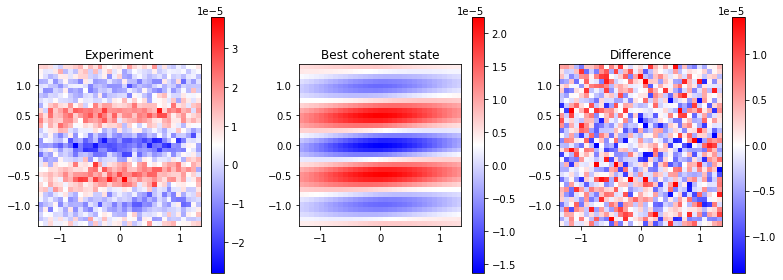

In [11]:
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# ==========================================================
# User settings
# ==========================================================

alpha_values = np.linspace(
    3,
    3.2,
    21,
)

rotation_values = np.linspace(
    -4,
    2,
    14,
)

# ==========================================================
# First experimental image
# ==========================================================

exp_img = state_list[0]

# ==========================================================
# Cost function
# ==========================================================

best_cost = np.inf

best_alpha = None
best_angle = None
best_sim = None

print("Searching alpha...")

for alpha in alpha_values:

    sim = simulate_characteristic_functions(
        T1=1e9,
        T2=1e9,
        alpha=alpha,
    )[0]

    for angle in rotation_values:

        sim_rot = rotate(
            sim,
            angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        sim_fit, _, _ = affine_fit(
            exp_img,
            sim_rot,
        )

        diff = exp_img[mask] - sim_fit[mask]

        cost = np.sqrt(
            np.mean(diff**2)
        )

        if cost < best_cost:

            best_cost = cost
            best_alpha = alpha
            best_angle = angle
            best_sim = sim_fit

print()
print("====================================")
print("Best coherent state")
print("====================================")
print(f"alpha = {best_alpha:.4f}")
print(f"angle = {best_angle:.2f} deg")

# ==========================================================
# Plot
# ==========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11,4),
)

titles = [
    "Experiment",
    "Best coherent state",
    "Difference",
]

images = [
    exp_img,
    best_sim,
    exp_img-best_sim,
]

for ax,title,img in zip(
    axes,
    titles,
    images,
):

    if title=="Difference":

        vmax=np.percentile(
            np.abs(img),
            99,
        )

        im=ax.pcolormesh(
            x_list[0],
            y_list[0],
            img,
            shading="auto",
            cmap="bwr",
            vmin=-vmax,
            vmax=vmax,
        )

    else:

        im=ax.pcolormesh(
            x_list[0],
            y_list[0],
            img,
            shading="auto",
            cmap="bwr",
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    plt.colorbar(im,ax=ax)

plt.tight_layout()
plt.show()

# ==========================================================
# Save value
# ==========================================================

initial_alpha = best_alpha

### 7. RUN GRID SEARCH FOR COARSE FITTING

T1 = 200.00 μs
T1 = 244.44 μs
T1 = 288.89 μs
T1 = 333.33 μs
T1 = 377.78 μs
T1 = 422.22 μs
T1 = 466.67 μs
T1 = 511.11 μs
T1 = 555.56 μs
T1 = 600.00 μs

Best parameters
----------------
T1 = 377.778 μs
T2 = 106.667 μs
Residue = 0.45125


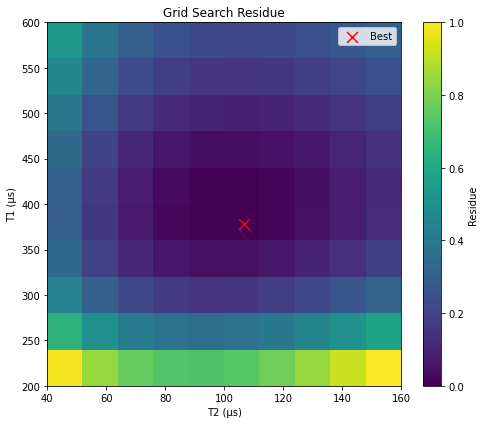

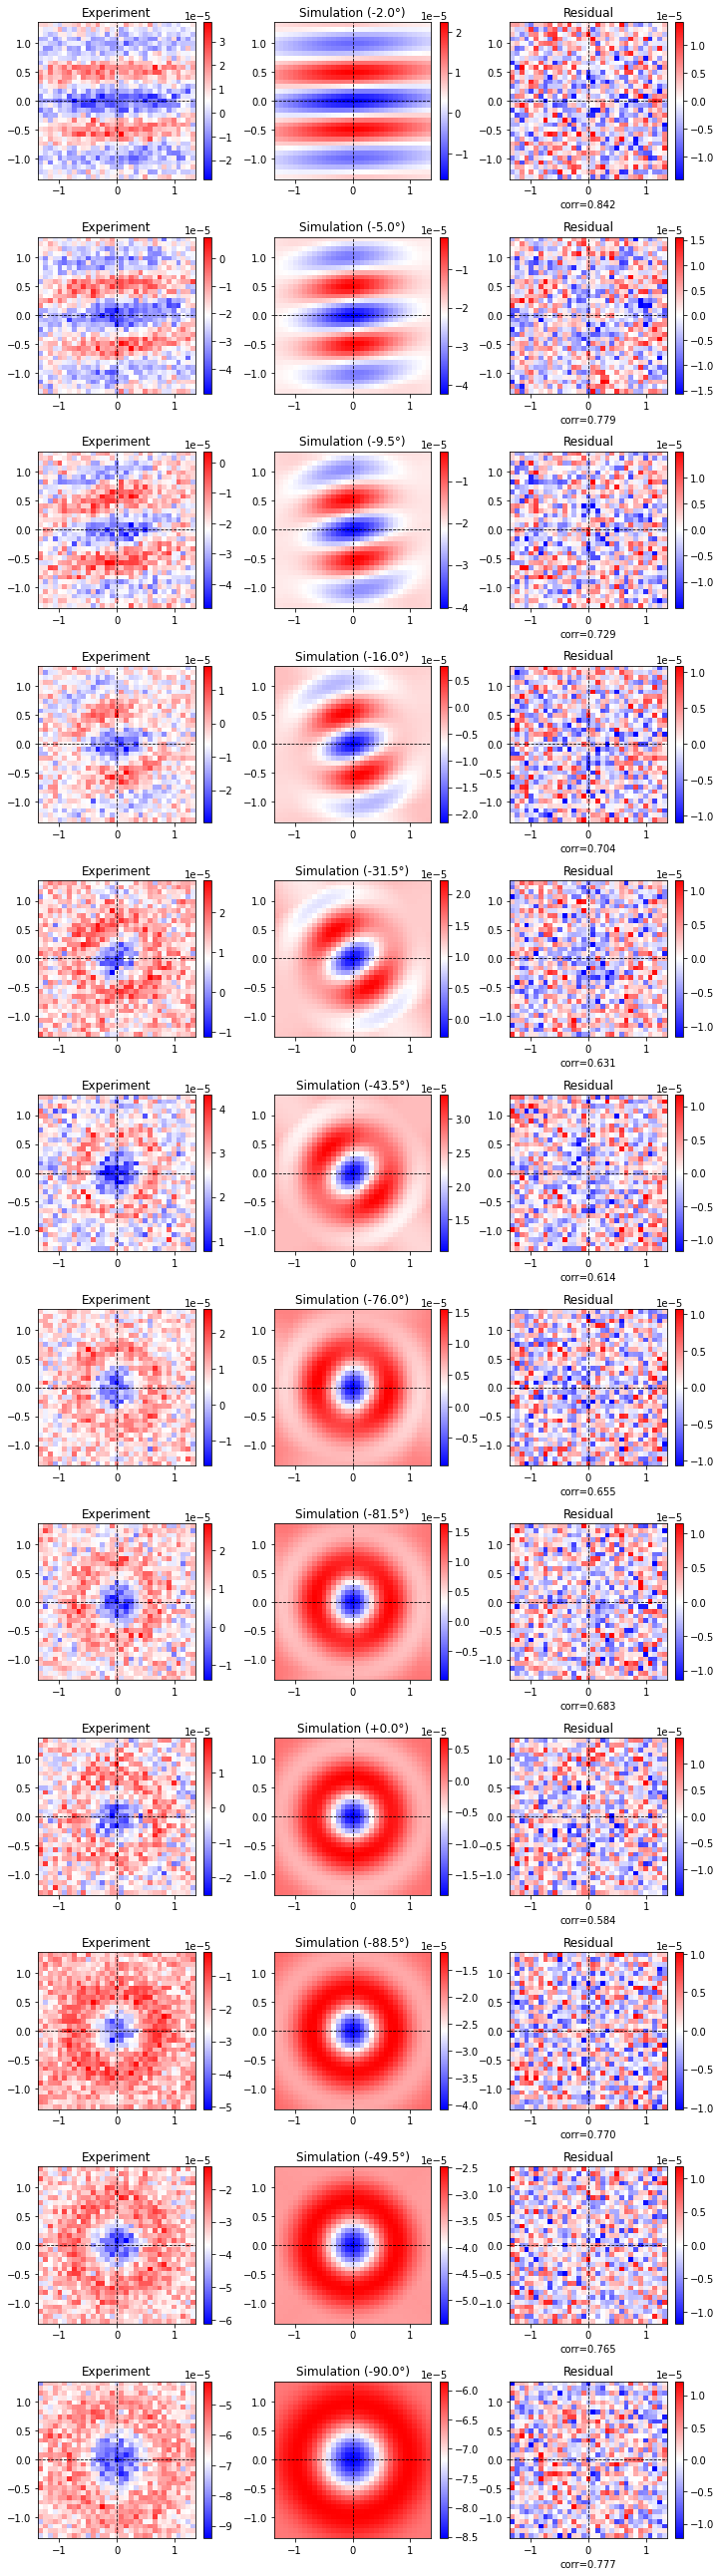


Average overlap: 0.711043843627939
Cost: 0.4512499818235594

Optimal image rotations:
   16 ns    -2.00°   corr=0.842
    4 μs    -5.00°   corr=0.779
    8 μs    -9.50°   corr=0.729
   16 μs   -16.00°   corr=0.704
   28 μs   -31.50°   corr=0.631
   44 μs   -43.50°   corr=0.614
   60 μs   -76.00°   corr=0.655
   80 μs   -81.50°   corr=0.683
  100 μs    +0.00°   corr=0.584
  140 μs   -88.50°   corr=0.770
  200 μs   -49.50°   corr=0.765
  400 μs   -90.00°   corr=0.777


In [93]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Parameter grid
# ==========================================================

T1_values = np.linspace(50_000, 150_000, 10)*4 # in ns
T2_values = np.linspace(10_000, 40_000, 10)*4   # in ns

cost = np.zeros((len(T1_values), len(T2_values)))

# ==========================================================
# Grid search
# ==========================================================

for i, T1 in enumerate(T1_values):

    print(f"T1 = {T1/1000:.2f} μs")

    for j, T2 in enumerate(T2_values):

        sim = simulate_characteristic_functions(
            T1=T1,
            T2=T2,
            alpha=initial_alpha,
        )

        cost[i,j] = residue(
            state_list,
            sim,
        )

# ==========================================================
# Best point
# ==========================================================

best = np.unravel_index(
    np.argmin(cost),
    cost.shape,
)

best_T1 = T1_values[best[0]]
best_T2 = T2_values[best[1]]

print()
print("Best parameters")
print("----------------")
print(f"T1 = {best_T1/1000:.3f} μs")
print(f"T2 = {best_T2/1000:.3f} μs")
print(f"Residue = {cost[best]:.5f}")

# ==========================================================
# Plot landscape
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(
    cost,
    origin="lower",
    aspect="auto",
    extent=[
        T2_values[0]/1000,
        T2_values[-1]/1000,
        T1_values[0]/1000,
        T1_values[-1]/1000,
    ],
)

plt.scatter(
    best_T2/1000,
    best_T1/1000,
    marker="x",
    s=120,
    c="red",
    label="Best",
)

plt.xlabel("T2 (μs)")
plt.ylabel("T1 (μs)")
plt.title("Grid Search Residue")

plt.colorbar(label="Residue")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Compare best simulation
# ==========================================================

best_sim = simulate_characteristic_functions(
    best_T1,
    best_T2,
    alpha=initial_alpha,
)
compare_experiment_simulation(
    state_list,
    best_sim,
)

# ----------------------------------------------------------
# Save fitted angles for later use
# ----------------------------------------------------------

best_angles, best_overlaps = extract_rotation_angles(
    state_list,
    best_sim,
)

print("\nOptimal image rotations:")

for t, angle, overlap in zip(
    decay_sweep_sorted,
    best_angles,
    best_overlaps,
):

    if t >= 1000:
        label = f"{t/1000:g} μs"
    else:
        label = f"{t:g} ns"

    print(
        f"{label:>8}   "
        f"{angle:+6.2f}°   "
        f"corr={overlap:.3f}"
    )


### 8. DEFINE COST FUNCTION AND FIT DETUNING

Estimated cavity detuning
Initial angle offset : -0.958 deg
Rotation slope       : -1.072 deg/us
Detuning             : -0.002978 MHz


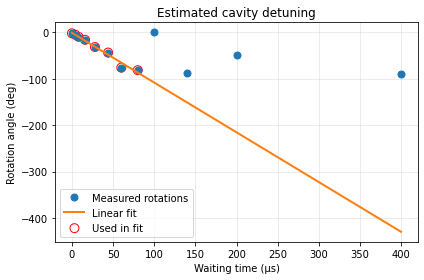


Initial parameters for optimization
-----------------------------------
T1       = 377.778 μs
T2       = 106.667 μs
Detuning = -0.002978 MHz
Offset   = -0.958 deg


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================================
# User settings
# ==========================================================

# Number of earliest points used for the fit.
# Later points become unreliable because of dephasing.
num_points_fit = 8

# ==========================================================
# Data
# ==========================================================

times_ns = np.asarray(decay_sweep_sorted)

times_us = times_ns / 1000

angles_deg = np.asarray(best_angles)

fit_times = times_us[:num_points_fit]
fit_angles = angles_deg[:num_points_fit]

# ==========================================================
# Linear model
# ==========================================================

def angle_model(t, offset_deg, slope_deg_per_us):
    return offset_deg + slope_deg_per_us*t

popt, pcov = curve_fit(
    angle_model,
    fit_times,
    fit_angles,
)

offset_deg = popt[0]
slope_deg_per_us = popt[1]

# ==========================================================
# Convert slope to detuning
# ==========================================================

# 360 degrees correspond to one oscillation.

detuning_MHz = slope_deg_per_us / 360.0

print("=====================================")
print("Estimated cavity detuning")
print("=====================================")
print(f"Initial angle offset : {offset_deg:.3f} deg")
print(f"Rotation slope       : {slope_deg_per_us:.3f} deg/us")
print(f"Detuning             : {detuning_MHz:.6f} MHz")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(6,4))

plt.plot(
    times_us,
    angles_deg,
    "o",
    ms=7,
    label="Measured rotations",
)

tt = np.linspace(
    0,
    times_us.max(),
    300,
)

plt.plot(
    tt,
    angle_model(tt, *popt),
    lw=2,
    label="Linear fit",
)

plt.scatter(
    fit_times,
    fit_angles,
    s=80,
    facecolors="none",
    edgecolors="red",
    label="Used in fit",
)

plt.xlabel("Waiting time (μs)")
plt.ylabel("Rotation angle (deg)")
plt.title("Estimated cavity detuning")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Values to use in optimizer
# ==========================================================

initial_T1 = best_T1
initial_T2 = best_T2
initial_detuning = detuning_MHz
initial_angle_offset = offset_deg

print("\nInitial parameters for optimization")
print("-----------------------------------")
print(f"T1       = {initial_T1/1000:.3f} μs")
print(f"T2       = {initial_T2/1000:.3f} μs")
print(f"Detuning = {initial_detuning:.6f} MHz")
print(f"Offset   = {initial_angle_offset:.3f} deg")

### 9. RUN OPTIMIZATION

Starting optimization
T1       = 377.778 μs
T2       = 106.667 μs
Detuning = -0.002978 MHz
Angle offset fixed = -0.96°
T1= 377.78 μs   T2= 106.67 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451239
T1= 396.67 μs   T2= 106.67 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451096
T1= 377.78 μs   T2= 112.00 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451492
T1= 377.78 μs   T2= 106.67 μs   Δ= -0.0031 MHz   alpha=  3.1100 cost=0.451334
T1= 390.37 μs   T2= 101.33 μs   Δ= -0.0031 MHz   alpha=  3.1100 cost=0.451047
T1= 396.67 μs   T2=  96.00 μs   Δ= -0.0031 MHz   alpha=  3.1100 cost=0.451136
T1= 398.77 μs   T2= 103.11 μs   Δ= -0.0029 MHz   alpha=  3.1100 cost=0.451011
T1= 409.26 μs   T2= 101.33 μs   Δ= -0.0028 MHz   alpha=  3.1100 cost=0.451132
T1= 412.76 μs   T2= 100.74 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451185
T1= 404.01 μs   T2= 102.22 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451060
T1= 398.77 μs   T2=  97.78 μs   Δ= -0.0030 MHz   alpha=  3.1100 cost=0.451031
T1= 387.92 μs   T2=  99

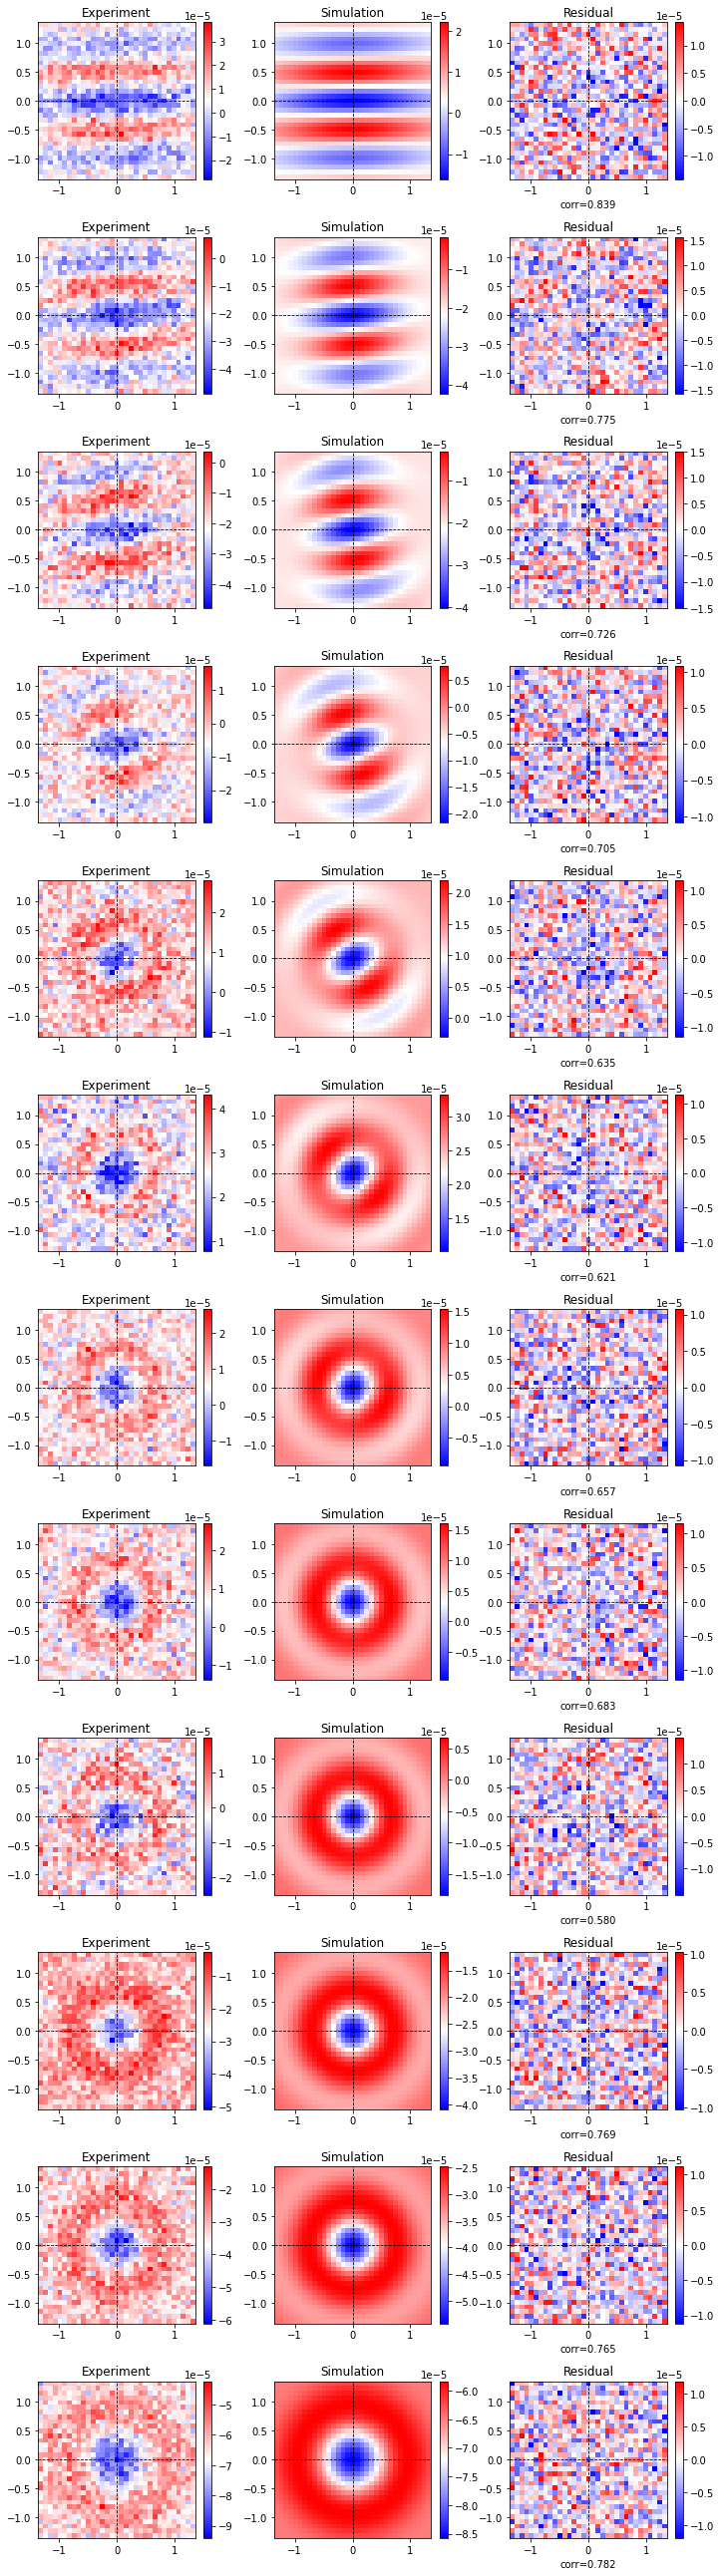


Average overlap: 0.7114133683168671
Cost: 0.45097411350834093


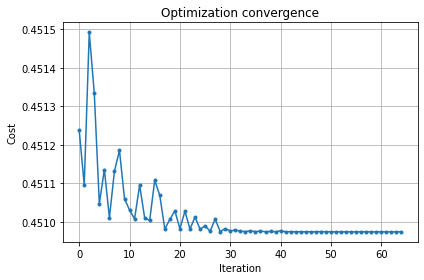

In [95]:
import numpy as np
from scipy.optimize import minimize

# ==========================================================
# Optimization history
# ==========================================================

history = []

# ==========================================================
# Cost function
# ==========================================================

def objective(params):

    T1, T2, detuning = params

    # ----------------------------------------------
    # Reject unphysical regions
    # ----------------------------------------------

    if T1 <= 1000:
        return 1e6

    if T2 <= 1000:
        return 1e6

    try:

        sim = simulate_characteristic_functions(
            T1=T1,
            T2=T2,
            detuning_MHz=detuning,
            angle_offset=initial_angle_offset,
            alpha=initial_alpha,
        )

        cost = residue_no_rotation(
            state_list,
            sim,
        )

    except Exception:

        return 1e6

    history.append(
        (
            T1,
            T2,
            detuning,
            cost,
        )
    )

    print(
        f"T1={T1/1000:7.2f} μs   "
        f"T2={T2/1000:7.2f} μs   "
        f"Δ={detuning:8.4f} MHz   "
        f"alpha={initial_alpha:8.4f} "
        f"cost={cost:.6f}"
    )

    return cost

# ==========================================================
# Initial guess
# ==========================================================

initial_guess = np.array([

    initial_T1,

    initial_T2,

    initial_detuning,

])

print("===================================")
print("Starting optimization")
print("===================================")

print(
    f"T1       = {initial_guess[0]/1000:.3f} μs"
)

print(
    f"T2       = {initial_guess[1]/1000:.3f} μs"
)

print(
    f"Detuning = {initial_guess[2]:.6f} MHz"
)

print(
    f"Angle offset fixed = {initial_angle_offset:.2f}°"
)

# ==========================================================
# Optimization
# ==========================================================

result = minimize(

    objective,

    initial_guess,

    method="Nelder-Mead",

    options={

        "maxiter":40,

        "disp":True,

        "xatol":100,

        "fatol":1e-5,

    },

)

best_T1, best_T2, best_detuning = result.x

print("\n===================================")
print("Optimization finished")
print("===================================")

print(f"T1       = {best_T1/1000:.3f} μs")
print(f"T2       = {best_T2/1000:.3f} μs")
print(f"Detuning = {best_detuning:.6f} MHz")
print(f"alpha = {initial_alpha:.2f}")
print(f"Cost     = {result.fun:.6f}")

# ==========================================================
# Simulate best solution
# ==========================================================

best_sim = simulate_characteristic_functions(

    T1=best_T1,

    T2=best_T2,

    detuning_MHz=best_detuning,

    angle_offset=initial_angle_offset,

    alpha=initial_alpha,

)

compare_experiment_simulation(

    state_list,

    best_sim,

    rotate_images = False

)

# ==========================================================
# Optimization history
# ==========================================================

history = np.asarray(history)

if len(history) > 0:

    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    plt.plot(
        history[:,3],
        "-o",
        ms=3,
    )

    plt.xlabel("Iteration")

    plt.ylabel("Cost")

    plt.title("Optimization convergence")

    plt.grid(True)

    plt.tight_layout()

    plt.show()